In [2]:
import pandas as pd
df = pd.read_csv('employee_salary_prediction_2500_updated.csv')
print(df.head())

   Employee_ID  Age  Experience_Years Education  Department  Job_Level  \
0        10001   59                34  Bachelor   Marketing          9   
1        10002   49                29  Bachelor          HR          9   
2        10003   35                10  Bachelor          IT          4   
3        10004   28                 3    Master  Operations          1   
4        10005   41                18    Master          IT          5   

   Performance_Rating  Projects_Completed  Certifications  Weekly_Work_Hours  \
0                 3.7                  30              13               38.1   
1                 3.2                  25              10               48.3   
2                 3.1                  13               4               41.7   
3                 3.1                   7               3               41.8   
4                 2.6                  18               7               47.2   

  Remote_Work City_Tier  Job_Satisfaction  Salary_LPA Salary_Status  
0   

In [3]:
df.columns

Index(['Employee_ID', 'Age', 'Experience_Years', 'Education', 'Department',
       'Job_Level', 'Performance_Rating', 'Projects_Completed',
       'Certifications', 'Weekly_Work_Hours', 'Remote_Work', 'City_Tier',
       'Job_Satisfaction', 'Salary_LPA', 'Salary_Status'],
      dtype='str')

In [4]:
df.dtypes

Employee_ID             int64
Age                     int64
Experience_Years        int64
Education                 str
Department                str
Job_Level               int64
Performance_Rating    float64
Projects_Completed      int64
Certifications          int64
Weekly_Work_Hours     float64
Remote_Work               str
City_Tier                 str
Job_Satisfaction        int64
Salary_LPA            float64
Salary_Status             str
dtype: object

In [5]:
df.rename(columns={
    'Projects_Completed':'Projects'
},inplace=True)

In [6]:
df.columns

Index(['Employee_ID', 'Age', 'Experience_Years', 'Education', 'Department',
       'Job_Level', 'Performance_Rating', 'Projects', 'Certifications',
       'Weekly_Work_Hours', 'Remote_Work', 'City_Tier', 'Job_Satisfaction',
       'Salary_LPA', 'Salary_Status'],
      dtype='str')

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2500, dtype: bool

In [8]:
df.isnull().sum()

Employee_ID           0
Age                   0
Experience_Years      0
Education             0
Department            0
Job_Level             0
Performance_Rating    0
Projects              0
Certifications        0
Weekly_Work_Hours     0
Remote_Work           0
City_Tier             0
Job_Satisfaction      0
Salary_LPA            0
Salary_Status         0
dtype: int64

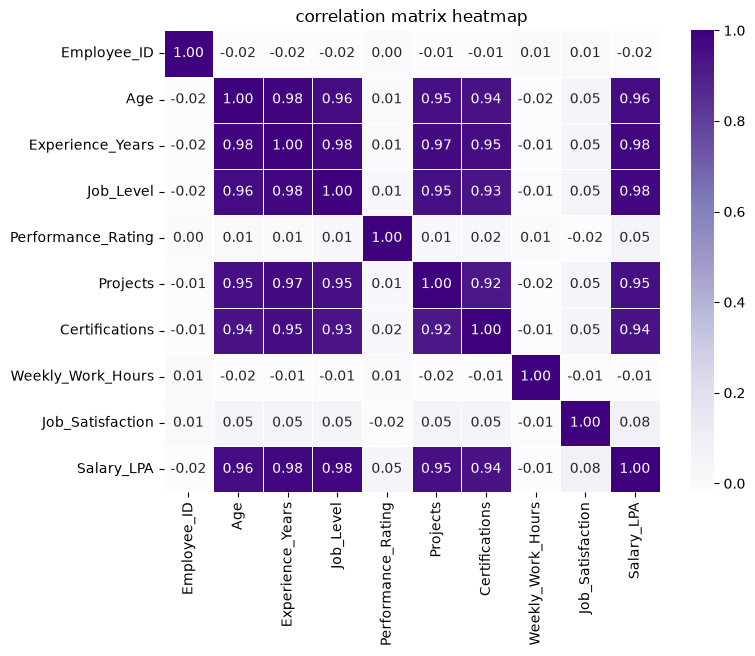

In [9]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix heatmap")
plt.show()


In [10]:
df.sort_values(by='Experience_Years',ascending=False).head(10)

,Employee_ID,Age,Experience_Years,Education,Department,Job_Level,Performance_Rating,Projects,Certifications,Weekly_Work_Hours,Remote_Work,City_Tier,Job_Satisfaction,Salary_LPA,Salary_Status
798,10799,60,40,Master,Operations,10,3.1,35,14,43.5,Yes,Tier 1,1,50.0,High
1182,11183,60,40,Bachelor,Sales,10,4.0,31,17,44.2,No,Tier 2,5,50.0,High
217,10218,60,40,Master,IT,10,3.6,33,16,38.9,Yes,Tier 2,1,50.0,High
723,10724,60,40,Bachelor,Marketing,10,3.4,36,15,44.7,Yes,Tier 3,3,50.0,High
2052,12053,60,40,High School,Marketing,10,3.6,34,15,48.8,Yes,Tier 3,2,50.0,High
104,10105,60,40,Bachelor,HR,10,3.9,35,14,37.3,Yes,Tier 2,4,50.0,High
1413,11414,60,40,Master,HR,10,3.1,37,13,52.5,No,Tier 1,4,50.0,High
2225,12226,60,40,Bachelor,IT,10,4.2,33,15,43.4,Yes,Tier 2,2,50.0,High
322,10323,60,39,High School,HR,10,3.4,38,15,53.6,No,Tier 2,4,50.0,High
1278,11279,59,39,Diploma,Operations,10,4.2,34,17,38.7,Yes,Tier 2,5,50.0,High


In [11]:
q1 = df["Salary_LPA"].quantile(0.25)
q3 = df["Salary_LPA"].quantile(0.75)

IQR = q3 - q1

lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

print("q1:", q1)
print("q3:", q3)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
outliers = df[
    (df["Salary_LPA"] < lower_limit) |
    (df["Salary_LPA"] > upper_limit)
]

print("\nSalary_LPA Outliers:",len(outliers))
print("\nSalary_LPA Outliers Data:\n")
print(outliers[[ "Employee_ID", "Salary_LPA"]].head(20))

q1: 23.13
q3: 46.3075
Lower Limit: -11.63625
Upper Limit: 81.07374999999999

Salary_LPA Outliers: 0

Salary_LPA Outliers Data:

Empty DataFrame
Columns: [Employee_ID, Salary_LPA]
Index: []


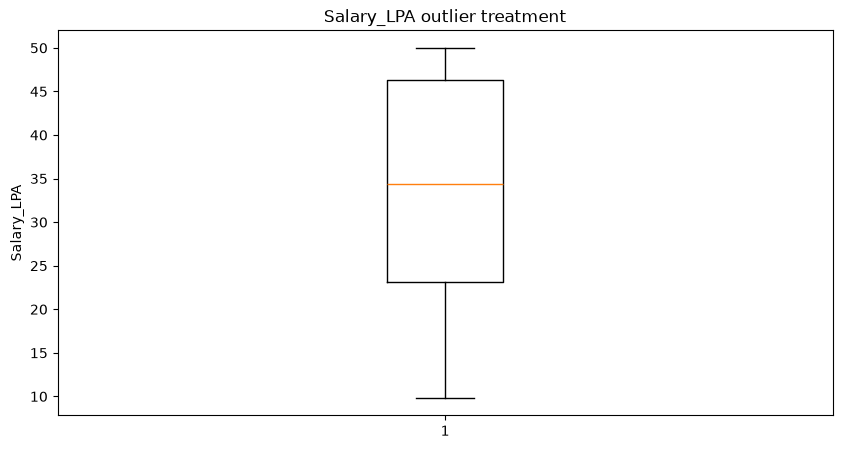

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.boxplot(df['Salary_LPA'])
plt.title("Salary_LPA outlier treatment")
plt.ylabel("Salary_LPA")
plt.show()

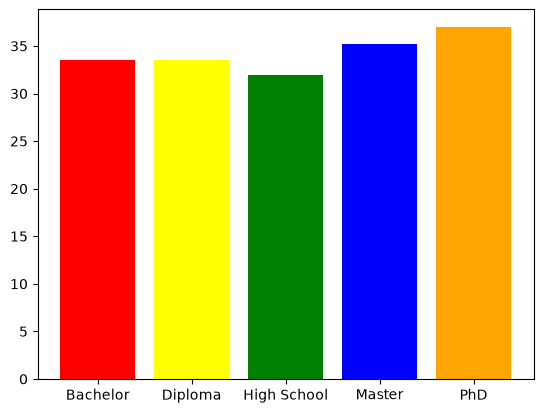

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
gender=df.groupby("Education")["Salary_LPA"].mean()
plt.bar(gender.index,
        gender.values,
        color=["red","yellow","green","blue","orange"]
        )
plt.title = ("Education Avg Salary")
plt.xlabel = ("Education")
plt.ylabel = ("Salary_LPA")
plt.show()


Average salary by Department:


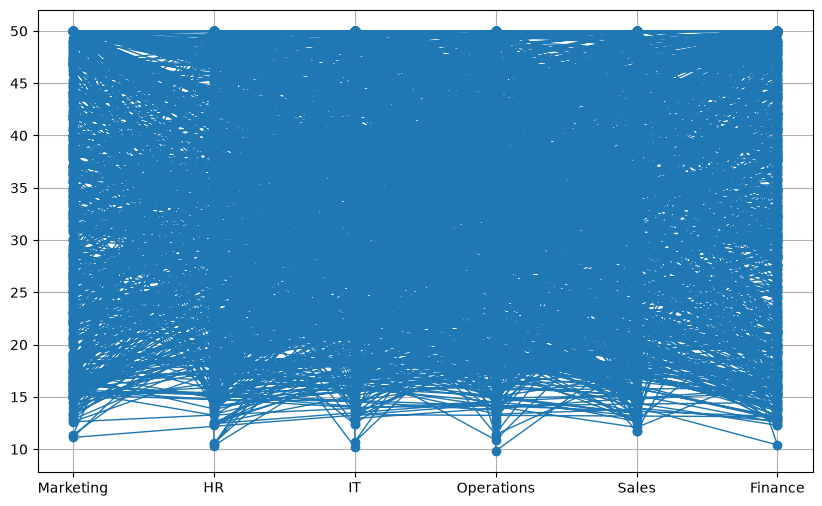

In [14]:
Department_vs_Salary = df.groupby("Department")["Salary_LPA"].mean()
print("\nAverage salary by Department:")
plt.figure(figsize=(10, 6))

plt.plot(
    df["Department"],
    df["Salary_LPA"],
    marker="o",
    linewidth=1
)

plt.xlabel = ("Department")
plt.ylabel = ("Salary (LPA)")
plt.title = ("Avg salary by department")
plt.grid(True)

plt.show()

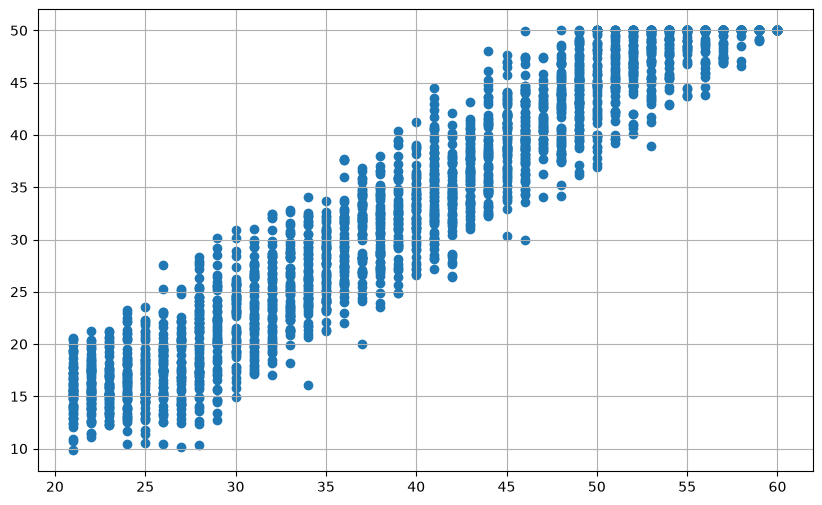

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Age"],
    df["Salary_LPA"]
)

plt.xlabel = ("Age")
plt.ylabel = ("Salary (LPA)")
plt.title = ("Age vs Salary")
plt.grid(True)

plt.show()

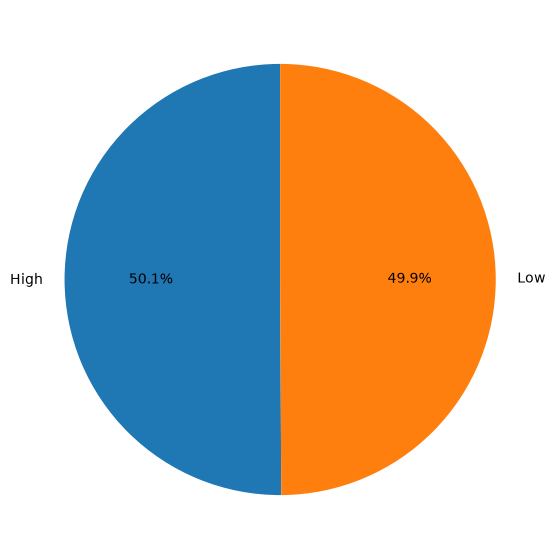

In [16]:
salary_counts = df["Salary_Status"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    salary_counts,
    labels=salary_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title = ("Salary Status Distribution")

plt.show()

First 5 Rows:
   Employee_ID  Age  Experience_Years Education  Department  Job_Level  \
0        10001   59                34  Bachelor   Marketing          9   
1        10002   49                29  Bachelor          HR          9   
2        10003   35                10  Bachelor          IT          4   
3        10004   28                 3    Master  Operations          1   
4        10005   41                18    Master          IT          5   

   Performance_Rating  Projects  Certifications  Weekly_Work_Hours  \
0                 3.7        30              13               38.1   
1                 3.2        25              10               48.3   
2                 3.1        13               4               41.7   
3                 3.1         7               3               41.8   
4                 2.6        18               7               47.2   

  Remote_Work City_Tier  Job_Satisfaction  Salary_LPA Salary_Status  
0          No    Tier 2                 5       50

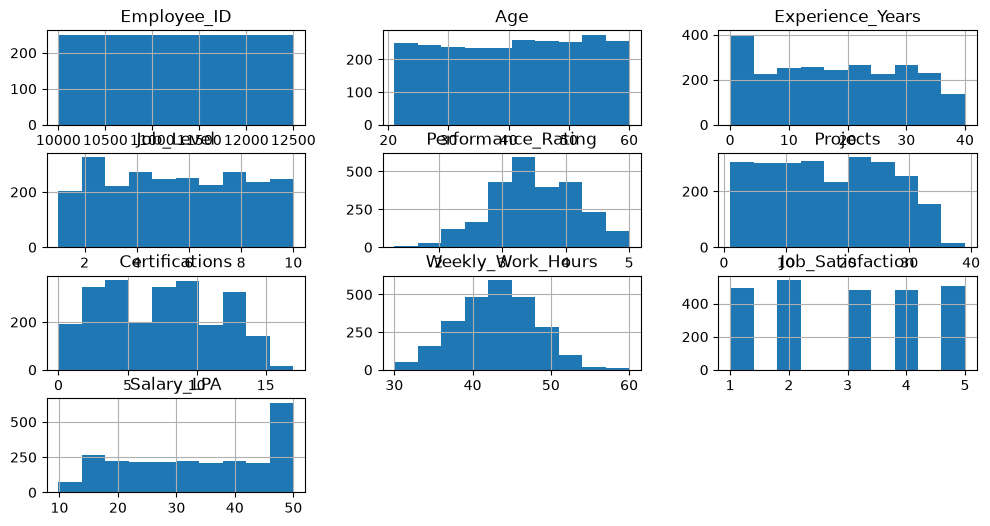

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(12,6))
plt.title = ("Feature Distributions")
plt.show()